In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import calendar
from haversine import haversine, Unit




In [5]:
#read the dataset
df = pd.read_csv(r"C:\Users\olisa\Documents\CODING IS FUN\Projects\CS1\2024all.csv")
df.sample(3) #Grab a sample of 3 rows from the dataset

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_type
2319177,FE8E8101F5F8A302,classic_bike,2024-06-16 11:19:40.737,2024-06-16 11:27:43.429,Clark St & Grace St,TA1307000127,Broadway & Cornelia Ave,13278,41.950780,-87.659172,41.945529,-87.646439,member
3815967,7B07EEF873D810B8,electric_bike,2024-08-27 12:17:34.696,2024-08-27 12:23:31.358,NaN,NaN,NaN,NaN,41.970000,-87.660000,41.960000,-87.650000,casual
5529,88CC6AF87062D7A2,classic_bike,2024-01-22 07:30:46,2024-01-22 07:39:36,McClurg Ct & Ohio St,TA1306000029,Orleans St & Hubbard St,636,41.892592,-87.617289,41.890028,-87.636618,member


In [4]:
df.tail(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_type
5860563,BD56BA20F42E4794,electric_bike,2024-12-11 08:23:46.564,2024-12-11 08:37:34.532,Clybourn Ave & Division St,TA1307000115,NaN,NaN,41.904634,-87.640518,41.880000,-87.630000,member
5860564,3074643A6B60B300,electric_bike,2024-12-09 12:26:15.677,2024-12-09 12:37:32.712,Canal St & Jackson Blvd,13138,NaN,NaN,41.878125,-87.639968,41.900000,-87.620000,member
5860565,15602635C5DF484E,electric_bike,2024-12-31 17:10:03.113,2024-12-31 17:17:21.838,Albany Ave & Bloomingdale Ave,15655,California Ave & Milwaukee Ave,13084,41.914027,-87.705126,41.922695,-87.697153,member
5860566,F15ABBA961560B75,electric_bike,2024-12-01 14:39:47.216,2024-12-01 14:45:21.268,Albany Ave & Bloomingdale Ave,15655,California Ave & Milwaukee Ave,13084,41.914003,-87.705099,41.922695,-87.697153,member
5860567,8AF273287533B527,electric_bike,2024-12-17 06:38:32.320,2024-12-17 06:46:27.167,Albany Ave & Bloomingdale Ave,15655,NaN,NaN,41.914027,-87.705126,41.920000,-87.690000,member


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860568 entries, 0 to 5860567
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_type         object 
dtypes: float64(4), object(9)
memory usage: 581.3+ MB


ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1073951
start_station_id      1073951
end_station_name      1104653
end_station_id        1104653
start_lat                   0
start_lng                   0
end_lat                  7232
end_lng                  7232
member_type                 0
dtype: int64

In [7]:
#Renaming columns for better readability

df = df.rename(columns={
    'ride_id': 'Ride_ID',
    'rideable_type': 'Rideable_Type',
    'started_at': 'Started_At',
    'ended_at': 'Ended_At',
    'start_station_name': 'Start_Station_Name',
    'start_station_id': 'Start_Station_ID',
    'end_station_name': 'End_Station_Name',
    'end_station_id': 'End_Station_ID',
    'start_lat': 'Start_Latitude',
    'start_lng': 'Start_Longitude',
    'end_lat': 'End_Latitude',
    'end_lng': 'End_Longitude',
    'member_type': 'Member_Type',
    
})

In [7]:
#Check the unique values in the 'Started_At' column to understand its format to extract the month information
df["Started_At"].str[5:7].value_counts().sort_index()

Started_At
01    144873
02    223164
03    301687
04    415025
05    609704
06    710747
07    749004
08    755804
09    820867
10    616292
11    335042
12    178359
Name: count, dtype: int64

In [8]:
df["Ended_At"].str[5:7].value_counts().sort_index()

Ended_At
01    144829
02    223187
03    301701
04    414931
05    609383
06    710932
07    748962
08    755639
09    821276
10    616281
11    335075
12    178372
Name: count, dtype: int64

In [10]:

df['Started_At'].str[5:7].isin(['06']).sum()


np.int64(710747)

In [9]:
def get_season(month):
    month = int(month)
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Extract month from string and create Season column
df['Season'] = df['Started_At'].str[5:7].apply(get_season)

In [10]:
df['Season'].unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

In [5]:
#Convert started_at and ended_at to datetime format

df['Started_At'] = pd.to_datetime(df['Started_At'], format="mixed")
df['Ended_At'] = pd.to_datetime(df['Ended_At'], format="mixed")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860568 entries, 0 to 5860567
Data columns (total 14 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Ride_ID             object        
 1   Rideable_Type       object        
 2   Started_At          datetime64[ns]
 3   Ended_At            datetime64[ns]
 4   Start_Station_Name  object        
 5   Start_Station_ID    object        
 6   End_Station_Name    object        
 7   End_Station_ID      object        
 8   Start_Latitude      float64       
 9   Start_Longitude     float64       
 10  End_Latitude        float64       
 11  End_Longitude       float64       
 12  Member_Type         object        
 13  Season              object        
dtypes: datetime64[ns](2), float64(4), object(8)
memory usage: 626.0+ MB


In [15]:
df["Started_At"].dt.month.value_counts().sort_index()

Started_At
1     144873
2     223164
3     301687
4     415025
5     609704
6     710747
7     749004
8     755804
9     820867
10    616292
11    335042
12    178359
Name: count, dtype: int64

In [16]:

df['Started_At'].dt.month.isin([11]).sum()

np.int64(335042)

In [6]:
df['Day_Of_Week'] = df['Started_At'].dt.day_name()

df['Ride_Length_Minutes'] = (df['Ended_At'] - df['Started_At']).dt.total_seconds() / 60
df.head(3)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860568 entries, 0 to 5860567
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Ride_ID              object        
 1   Rideable_Type        object        
 2   Started_At           datetime64[ns]
 3   Ended_At             datetime64[ns]
 4   Start_Station_Name   object        
 5   Start_Station_ID     object        
 6   End_Station_Name     object        
 7   End_Station_ID       object        
 8   Start_Latitude       float64       
 9   Start_Longitude      float64       
 10  End_Latitude         float64       
 11  End_Longitude        float64       
 12  Member_Type          object        
 13  Season               object        
 14  Day_Of_Week          object        
 15  Ride_Length_Minutes  float64       
dtypes: datetime64[ns](2), float64(5), object(9)
memory usage: 715.4+ MB


In [8]:
#Filtering Data
#df = df.dropna(subset=['started_at', 'ended_at'])

# 2. Handle station info
#station_cols = [
#    'start_station_name', 'start_station_id',
#    'end_station_name', 'end_station_id'
#]
#df[station_cols] = df[station_cols].fillna('Unknown')

# 3. Handle rare missing end locations
#df = df.dropna(subset=['end_lat', 'end_lng'])


In [18]:
df.isnull().sum()


Ride_ID                      0
Rideable_Type                0
Started_At                   0
Ended_At                     0
Start_Station_Name     1073951
Start_Station_ID       1073951
End_Station_Name       1104653
End_Station_ID         1104653
Start_Latitude               0
Start_Longitude              0
End_Latitude              7232
End_Longitude             7232
Member_Type                  0
Season                       0
Day_Of_Week                  0
Ride_Length_Minutes          0
dtype: int64

In [13]:
(df['Ride_Length_Minutes'] == 0).sum()
(df == 0).sum()

Ride_ID                  0
Rideable_Type            0
Started_At               0
Ended_At                 0
Start_Station_Name       0
Start_Station_ID         0
End_Station_Name         0
End_Station_ID           0
Start_Latitude           0
Start_Longitude          0
End_Latitude             0
End_Longitude            0
Member_Type              0
Season                   0
Day_Of_Week              0
Ride_Length_Minutes    496
dtype: int64

In [123]:
(df == 'casual').any()

Ride_ID                False
Rideable_Type          False
Started_At             False
Ended_At               False
Start_Station_Name     False
Start_Station_ID       False
End_Station_Name       False
End_Station_ID         False
Start_Latitude         False
Start_Longitude        False
End_Latitude           False
End_Longitude          False
Member_Type             True
Season                 False
Day_Of_Week            False
Ride_Length_Minutes    False
Month                  False
Month_Name             False
Ride_Distance          False
dtype: bool

In [20]:
df.nunique()

Ride_ID                5860357
Rideable_Type                3
Started_At             5649600
Ended_At               5652165
Start_Station_Name        1808
Start_Station_ID          1763
End_Station_Name          1815
End_Station_ID            1768
Start_Latitude          531777
Start_Longitude         513647
End_Latitude              2782
End_Longitude             2802
Member_Type                  2
Season                       4
Day_Of_Week                  7
Ride_Length_Minutes    1761741
dtype: int64

In [7]:
# Convert datetime columns to datetime type
# Convert categorical columns to 'category' dtype

categorical_cols = [
    'Rideable_Type',
    'Season',
    'Day_Of_Week',
    'Member_Type'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860568 entries, 0 to 5860567
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Ride_ID              object        
 1   Rideable_Type        category      
 2   Started_At           datetime64[ns]
 3   Ended_At             datetime64[ns]
 4   Start_Station_Name   object        
 5   Start_Station_ID     object        
 6   End_Station_Name     object        
 7   End_Station_ID       object        
 8   Start_Latitude       float64       
 9   Start_Longitude      float64       
 10  End_Latitude         float64       
 11  End_Longitude        float64       
 12  Member_Type          category      
 13  Season               category      
 14  Day_Of_Week          category      
 15  Ride_Length_Minutes  float64       
dtypes: category(4), datetime64[ns](2), float64(5), object(5)
memory usage: 558.9+ MB


In [30]:
#Understanding filtering task
df = df[df['End_Latitude'].notna() & df['End_Longitude'].notna()]

df.head(3)


,Ride_ID,Rideable_Type,Started_At,Ended_At,Start_Station_Name,Start_Station_ID,End_Station_Name,End_Station_ID,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Member_Type,Season,Day_of_Week,Ride_Length_Minutes,Day_Of_Week
0,C1D650626C8C899A,electric_bike,2024-01-12 15:30:27,2024-01-12 15:37:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.903267,-87.634737,41.889177,-87.638506,member,Winter,Friday,7.533333,Friday
1,EECD38BDB25BFCB0,electric_bike,2024-01-08 15:45:46,2024-01-08 15:52:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902937,-87.634440,41.889177,-87.638506,member,Winter,Monday,7.216667,Monday
2,F4A9CE78061F17F7,electric_bike,2024-01-27 12:27:19,2024-01-27 12:35:19,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902951,-87.634470,41.889177,-87.638506,member,Winter,Saturday,8.000000,Saturday


In [31]:

df = df[(df['Start_Latitude'] != 0) & (df['Start_Longitude'] != 0) & (df['End_Longitude'] != 0) & (df['End_Latitude'] != 0)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5853336 entries, 0 to 5860567
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Ride_ID              object        
 1   Rideable_Type        category      
 2   Started_At           datetime64[ns]
 3   Ended_At             datetime64[ns]
 4   Start_Station_Name   object        
 5   Start_Station_ID     object        
 6   End_Station_Name     object        
 7   End_Station_ID       object        
 8   Start_Latitude       float64       
 9   Start_Longitude      float64       
 10  End_Latitude         float64       
 11  End_Longitude        float64       
 12  Member_Type          category      
 13  Season               category      
 14  Day_of_Week          object        
 15  Ride_Length_Minutes  float64       
 16  Day_Of_Week          category      
dtypes: category(4), datetime64[ns](2), float64(5), object(6)
memory usage: 647.5+ MB


In [16]:
df['Ride_Length_Minutes'].nunique()

1761741

In [17]:
df['Ride_Distance'] = df.apply(lambda row: haversine((row['Start_Latitude'], row['Start_Longitude']), (row['End_Latitude'], row['End_Longitude']), unit=Unit.KILOMETERS), axis=1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860568 entries, 0 to 5860567
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Ride_ID              object        
 1   Rideable_Type        category      
 2   Started_At           datetime64[ns]
 3   Ended_At             datetime64[ns]
 4   Start_Station_Name   object        
 5   Start_Station_ID     object        
 6   End_Station_Name     object        
 7   End_Station_ID       object        
 8   Start_Latitude       float64       
 9   Start_Longitude      float64       
 10  End_Latitude         float64       
 11  End_Longitude        float64       
 12  Member_Type          category      
 13  Season               category      
 14  Day_Of_Week          category      
 15  Ride_Length_Minutes  float64       
dtypes: category(4), datetime64[ns](2), float64(5), object(5)
memory usage: 558.9+ MB


In [24]:
df["Started_At"].dt.month.value_counts().sort_index()


Started_At
1     144873
2     223164
3     301687
4     415025
5     609704
6     710747
7     749004
8     755804
9     820867
10    616292
11    335042
12    178359
Name: count, dtype: int64

In [146]:
#df["Started_At"].dt.month.nunique()
df["Started_At"].min(), df["Started_At"].max()
#df["Started_At"].dt.to_period("M").nunique()


(Timestamp('2024-01-01 00:00:39'), Timestamp('2024-12-31 23:56:49.854000'))

In [28]:
df["Started_At"].sort_values().tail(10)

5846964   2024-12-31 23:49:45.399
5772629   2024-12-31 23:49:48.628
5684312   2024-12-31 23:50:06.749
5846584   2024-12-31 23:51:33.562
5790977   2024-12-31 23:52:30.628
5738240   2024-12-31 23:52:49.117
5721885   2024-12-31 23:54:01.903
5684478   2024-12-31 23:54:37.045
5801694   2024-12-31 23:56:38.214
5774615   2024-12-31 23:56:49.854
Name: Started_At, dtype: datetime64[ns]

In [147]:
df["Started_At"].isna().sum()

np.int64(0)

In [148]:
df.isna().sum()

Ride_ID                      0
Rideable_Type                0
Started_At                   0
Ended_At                     0
Start_Station_Name     1073951
Start_Station_ID       1073951
End_Station_Name       1104653
End_Station_ID         1104653
Start_Latitude               0
Start_Longitude              0
End_Latitude              7232
End_Longitude             7232
Member_Type                  0
Season                       0
Day_Of_Week                  0
Ride_Length_Minutes          0
Ride_Distance             7232
dtype: int64

In [ ]:
df_start_station_u = df[(df['Start_Station_Name'] == 'Unknown')].groupby(['Start_Latitude','Start_Longitude'])['Ride_ID'].count().reset_index()
df_end_station_u = df[(df['End_Station_Name'] == 'Unknown')].groupby(['End_Latitude','End_Longitude'])['Ride_ID'].count().reset_index()

In [18]:
# Calculate mean and standard deviation
mean = df['Ride_Length_Minutes'].mean()
std_dev = df['Ride_Length_Minutes'].std()

# Calculate z-score for each data point
z_score = (df['Ride_Length_Minutes'] - mean) / std_dev

# Set threshold (e.g., 3 standard deviations)
threshold = 3

# Identify extreme outliers
extreme_outliers = df[z_score > threshold]

# Remove extreme outliers from DataFrame
df = df[z_score <= threshold]

C:\Users\olisa\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


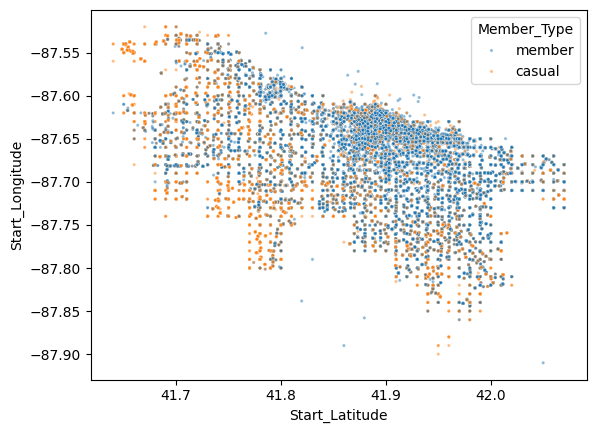

In [12]:
sns.scatterplot(data=df, x='Start_Latitude', y='Start_Longitude', s=5, hue='Member_Type', alpha=0.5)

plt.show()

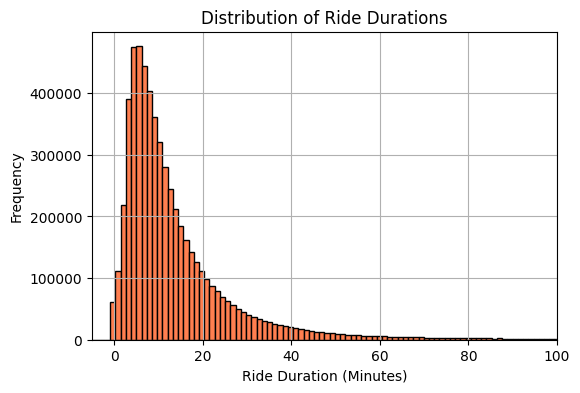

In [116]:

plt.figure(figsize=(6,4))
plt.hist(df['Ride_Length_Minutes'], bins=2500, color='coral', edgecolor='black')
plt.title('Distribution of Ride Durations')
plt.xlabel('Ride Duration (Minutes)')
plt.ylabel('Frequency')
plt.grid(True)

plt.xlim(-5, 100)
plt.show()

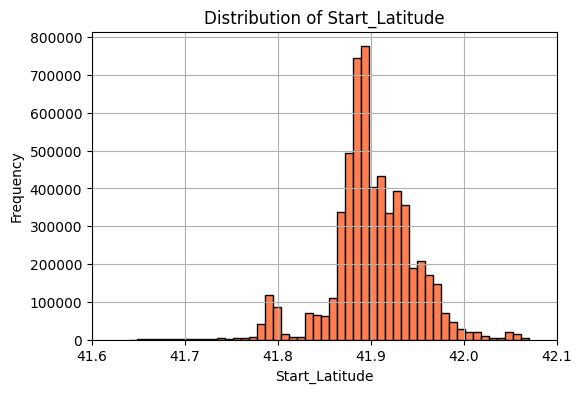

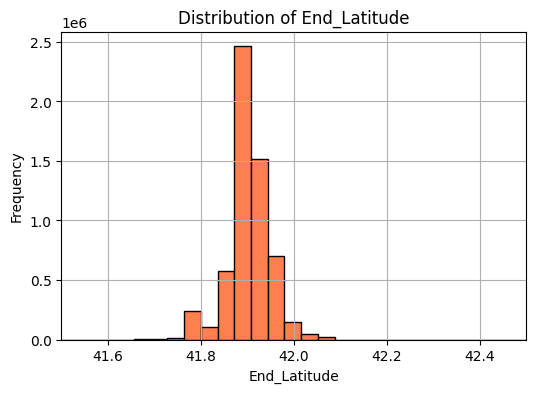

In [24]:
plot_config = {
    'Start_Latitude': {'bins': 50, 'xlim': (41.6, 42.1)},
    'End_Latitude': {'bins': 2000, 'xlim': (41.5, 42.5)}
}

for col, config in plot_config.items():

    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=config['bins'], color='coral', edgecolor='black')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)

    plt.xlim(config['xlim'])
    plt.show()

In [53]:
df['End_Longitude'].

np.float64(-87.64645450625602)

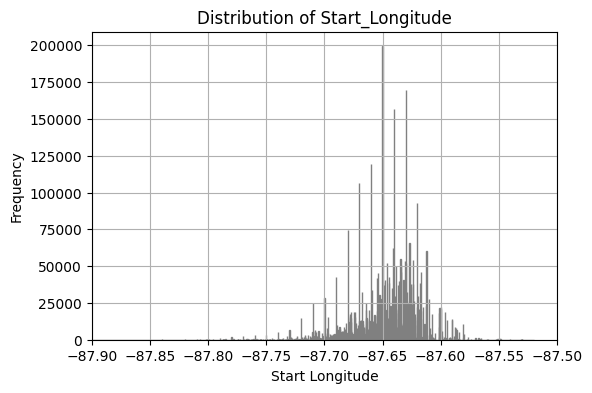

In [38]:


plt.figure(figsize=(6,4))
plt.hist(df['Start_Longitude'], bins=2500, color='lightblue', edgecolor='grey')
plt.title('Distribution of Start_Longitude')
plt.xlabel('Start Longitude')
plt.ylabel('Frequency')
plt.grid(True)

plt.xlim(-87.9, -87.5)
plt.show()

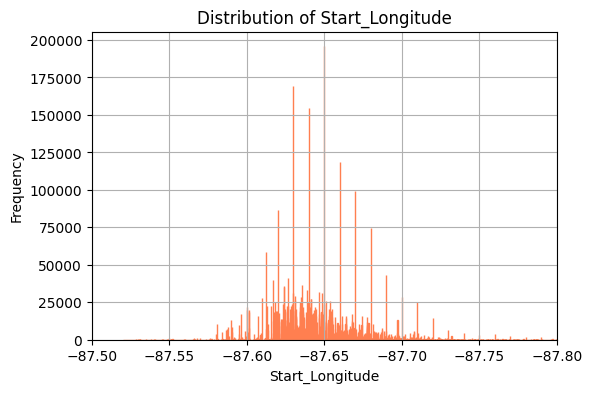

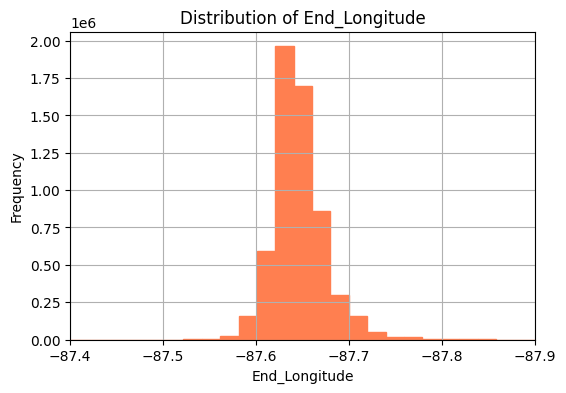

In [117]:
plot_config1 = {
    'Start_Longitude': {'bins': 10000, 'xlim': (-87.5, -87.8)},
    'End_Longitude': {'bins': 15000, 'xlim': (-87.4, -87.9)}
}

for col1, config1 in plot_config1.items():

    plt.figure(figsize=(6,4))
    plt.hist(df[col1], bins=config1['bins'], color='coral', edgecolor='coral')

    plt.title(f'Distribution of {col1}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')
    plt.grid(True)

    plt.xlim(config1['xlim'])
    plt.show()

In [ ]:
print(df['End_Latitude'].nunique() & df['Start_Latitude'].nunique())

2132

               Count
Member_Type         
member       3703880
casual       2137877
Total        5841757


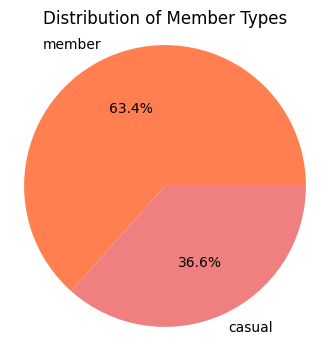

In [118]:
member_type = df["Member_Type"].value_counts()
total_count = member_type.sum()
member_type_df = pd.DataFrame(member_type)
member_type_df.columns = ['Count']
member_type_df.loc['Total'] = total_count

plt.figure(figsize=(4, 4))
plt.pie(member_type.values, colors = ['coral', 'lightcoral'], labels=member_type.index, autopct='%1.1f%%')
plt.title('Distribution of Member Types')
plt.axis('equal')

print(member_type_df)

                    Count
Rideable_Type            
electric_bike     2978412
classic_bike      2719047
electric_scooter   144298
Total             5841757


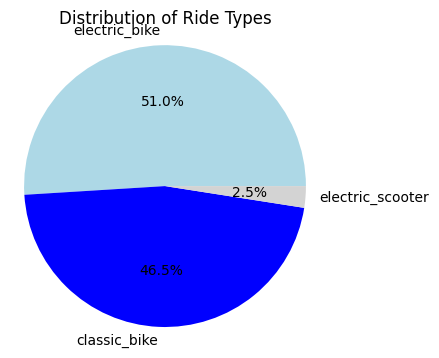

In [69]:
ride_type = df["Rideable_Type"].value_counts()
total_count = ride_type.sum()
ride_type_df = pd.DataFrame(ride_type)
ride_type_df.columns = ['Count']
ride_type_df.loc['Total'] = total_count

plt.figure(figsize=(4, 4))
plt.pie(ride_type.values, colors=['lightblue', 'blue', 'lightgray'], labels=ride_type.index, autopct='%1.1f%%')
plt.title('Distribution of Ride Types')
plt.axis('equal')

print(ride_type_df)

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1958056320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bike_types = df.groupby(["Rideable_Type", "Member_Type"])['Ride_ID'].count().reset_index()


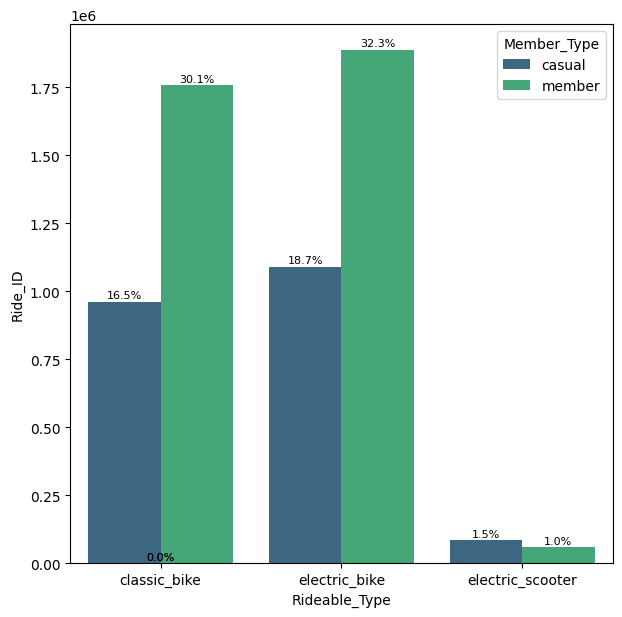

      Rideable_Type Member_Type  Ride_ID
0      classic_bike      casual   961660
1      classic_bike      member  1757387
2     electric_bike      casual  1091038
3     electric_bike      member  1887374
4  electric_scooter      casual    85179
5  electric_scooter      member    59119


In [64]:
bike_types = df.groupby(["Rideable_Type", "Member_Type"])['Ride_ID'].count().reset_index()

plt.figure(figsize=(7, 7))
sns.barplot(x='Rideable_Type', y='Ride_ID', hue='Member_Type', data=bike_types, palette="viridis")

total_counts = sum([p.get_height() for p in plt.gca().patches])
for p in plt.gca().patches:
    plt.annotate('{:.1f}%'.format(p.get_height() / total_counts * 100),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 1),
                 textcoords='offset points')
plt.show()

print(bike_types)

In [35]:
type(df['Started_At'])

pandas.core.series.Series

In [72]:
months = df['Started_At'].dt.month
hours = df['Started_At'].dt.hour
days = df['Started_At'].dt.day
week_order = ["Monday","Tuesday","Wednesday",'Thursday','Friday','Saturday','Sunday']
df['Day_Of_Week'] = pd.Categorical(df['Day_Of_Week'], categories=week_order, ordered=True)
season_order = ["Spring","Summer","Fall","Winter"]
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)
hours_order = sorted(hours.unique())
days_order = sorted(days.unique())

annual_members = df[df['Member_Type']=='member']
casual_members = df[df['Member_Type']=='casual']

In [38]:
#df['Started_At'].dtype
#df["Started_At"].isna.sum()
df["Started_At"].dt.to_period("M").value_counts().sum()

np.int64(5860568)

In [39]:
len(df)

5860568

In [73]:
monthly_counts = df.groupby([months, "Member_Type"])['Ride_ID'].count().reset_index()
month_names = [calendar.month_name[month] for month in sorted(months.unique())]
day_counts = df.groupby([df["Started_At"].dt.day,"Member_Type"])['Ride_ID'].count().reset_index()
week_counts = df.groupby(["Day_Of_Week","Member_Type"])['Ride_ID'].count().reset_index()
hour_counts = df.groupby([df["Started_At"].dt.hour,"Member_Type"])['Ride_ID'].count().reset_index()
season_counts = df.groupby(["Season","Member_Type"])['Ride_ID'].count().reset_index()

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1808866152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby([months, "Member_Type"])['Ride_ID'].count().reset_index()
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1808866152.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_counts = df.groupby([df["Started_At"].dt.day,"Member_Type"])['Ride_ID'].count().reset_index()
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1808866152.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

In [74]:
data = {
    (0, 0): {'x':'Started_At', 'y':'Ride_ID', 'hue': 'Member_Type', 'title': 'Trips Taken in a Year', 'xlabel': 'Month', 'xticklabels': month_names, 'xtickrotation': 30, 'data': monthly_counts},
    (0, 1): {'x':'Day_Of_Week', 'y':'Ride_ID', 'hue': 'Member_Type', 'title': 'Trips Taken in a Week', 'xlabel': 'Day', 'xticklabels': week_order, 'xtickrotation': 30, 'data': week_counts},
    (1, 0): {'x':'Started_At', 'y':'Ride_ID', 'hue': 'Member_Type', 'title': 'Trips Taken in a Month', 'xlabel': 'Date', 'xticklabels': days_order, 'xtickrotation': 60, 'data': day_counts},
    (1, 1): {'x':'Started_At', 'y':'Ride_ID', 'hue': 'Member_Type', 'title': 'Trips Taken in a Day', 'xlabel': 'Hour', 'xticklabels': hours_order, 'xtickrotation': 60, 'data': hour_counts}
}
for (i, j), plot_data in data.items():
    print(plot_data['data'].columns)

Index(['Started_At', 'Member_Type', 'Ride_ID'], dtype='object')
Index(['Day_Of_Week', 'Member_Type', 'Ride_ID'], dtype='object')
Index(['Started_At', 'Member_Type', 'Ride_ID'], dtype='object')
Index(['Started_At', 'Member_Type', 'Ride_ID'], dtype='object')


In [75]:
#print(plot_data['data'].head())
print(plot_data['data'].columns)
print(type(plot_data))

Index(['Started_At', 'Member_Type', 'Ride_ID'], dtype='object')
<class 'dict'>


C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3836183494.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3836183494.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3836183494.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3836183494.py:13: UserWarning: set_ticklabels() should only be used with a

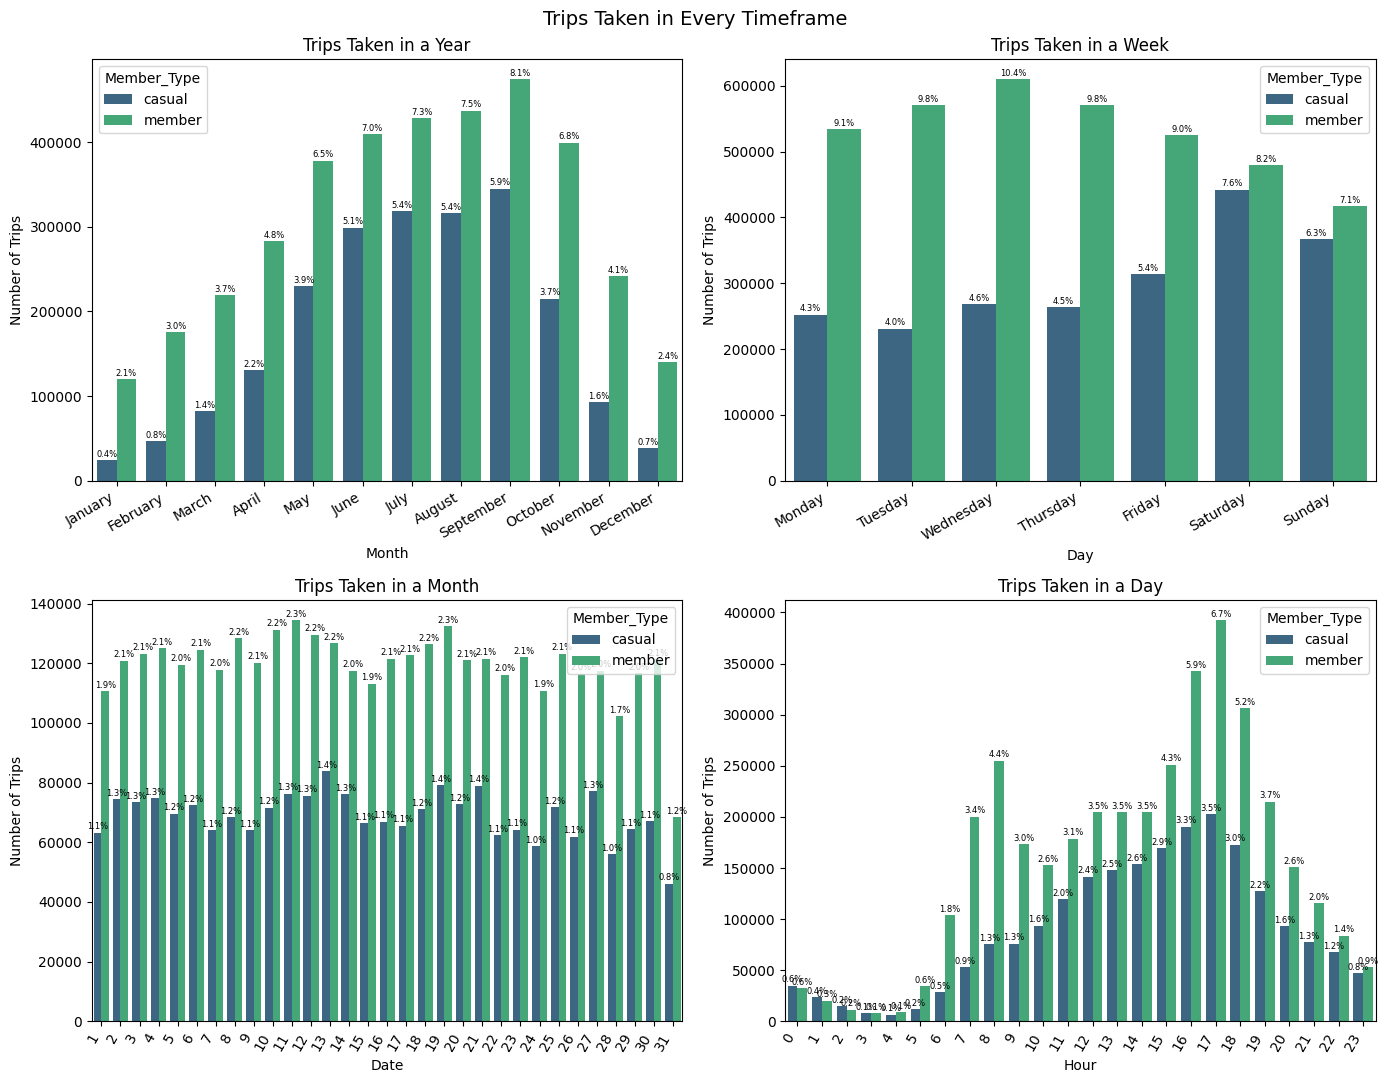

In [76]:


fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharey=False)

for (i, j), plot_data in data.items():
    
    ax = axes[i, j]
    
    sns.barplot(x=plot_data['x'],y=plot_data['y'],hue=plot_data['hue'],data=plot_data['data'],ax=ax,palette='viridis') 

    ax.set_title(plot_data['title'])
    ax.set_xlabel(plot_data['xlabel'])
    ax.set_ylabel('Number of Trips')

    ax.set_xticklabels(plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')

    # Calculate total bars in subplot
    total = sum(p.get_height() for p in ax.patches)

    for p in ax.patches:
        height = p.get_height()

        if height > 0:
            ax.annotate(
                f'{height/total*100:.1f}%',
                (p.get_x() + p.get_width()/2., height),
                ha='center',
                va='bottom',
                fontsize=6,
                xytext=(0,1),
                textcoords='offset points'
            )

plt.suptitle("Trips Taken in Every Timeframe", fontsize=14)

plt.tight_layout()
plt.show()

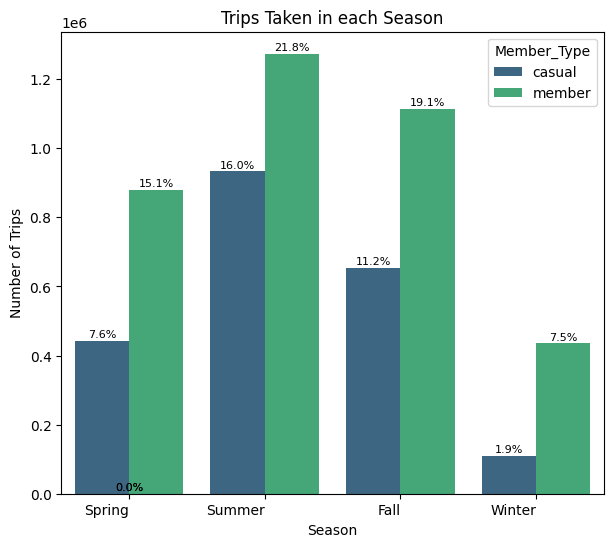

In [121]:
plt.figure(figsize=(7,6))

sns.barplot(x='Season', y='Ride_ID',hue='Member_Type', data=season_counts, palette='viridis')
plt.title('Trips Taken in each Season')
plt.xlabel("Season")
plt.ylabel('Number of Trips')
plt.xticks(ticks=range(len(season_order)), labels=season_order, rotation=0, ha='right')
total_counts = sum([p.get_height() for p in plt.gca().patches])
for p in plt.gca().patches:
    plt.annotate('{:.1f}%'.format(p.get_height() / total_counts * 100),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 1),
                 textcoords='offset points')
    



C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1625373795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=var, y="Member_Type", data=df, ax=ax1[i], palette='viridis')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1625373795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=var, y="Member_Type", data=df, ax=ax1[i], palette='viridis')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1625373795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=var, y="Member_Type", data=df, ax=ax1[i], palette='viridis')
C:\Users\olis

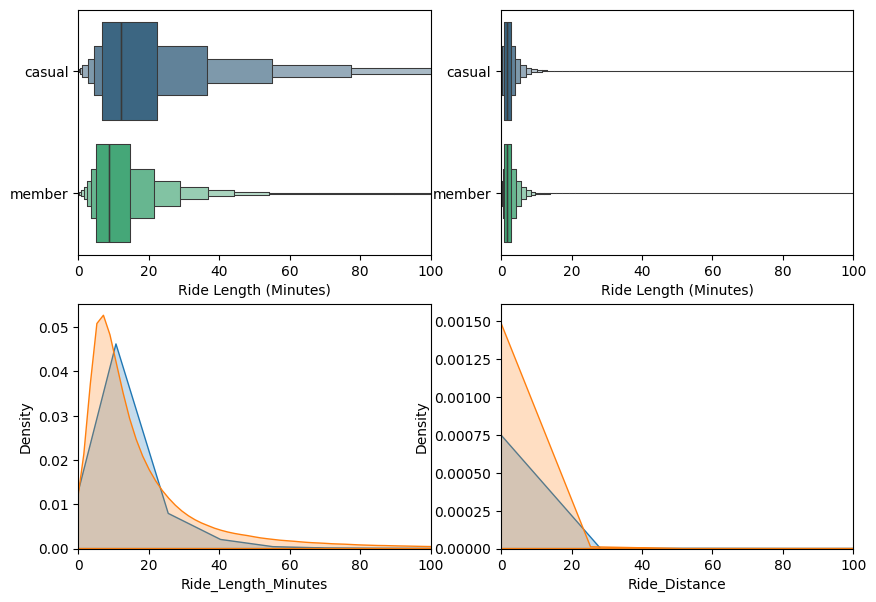

In [127]:
fig, axes = plt.subplots(2,2,figsize=(10,7))
for i, var in enumerate(['Ride_Length_Minutes', 'Ride_Distance']):
    for j, user in enumerate(df['Member_Type'].unique()):
        sns.kdeplot(df[df['Member_Type'] == user][var], ax=axes[i,1], fill=True, label=user)        
        sns.boxenplot(x=var, y="Member_Type", data=df, ax=axes[i,0], palette='viridis')
        axes[i,0].set(xlabel="Ride Length (Minutes)", ylabel="")
        axes[i,1].set(ylabel="Density")
        axes[i,0].set_xlim(0, 100)
        axes[i,1].set_xlim(0, 100)
        
        

plt.show()

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2266955198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


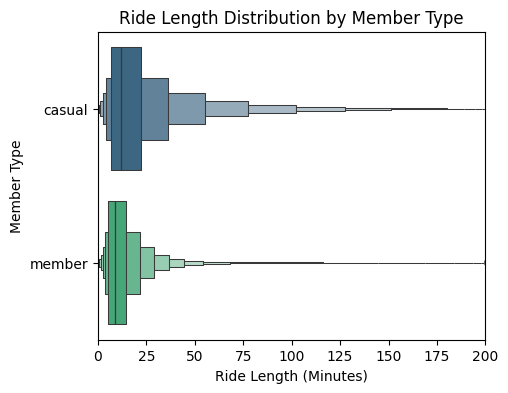

In [ ]:
plt.figure(figsize=(5,4))

sns.boxenplot(x='Ride_Length_Minutes',y='Member_Type',data=df,palette='viridis')
plt.title('Ride Length Distribution by Member Type')
plt.xlabel('Ride Length (Minutes)')
plt.ylabel('Member Type')
plt.xlim(0, 200)

plt.show()


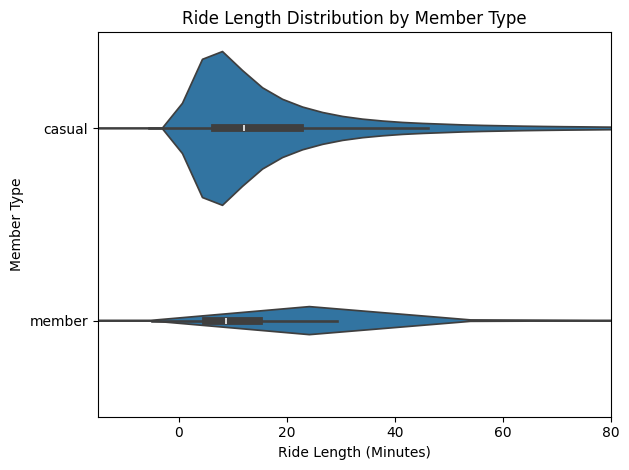

In [120]:
sns.violinplot(x='Ride_Length_Minutes', y='Member_Type', data=df)

# xlim is a matplotlib function; call via plt.xlim
plt.xlim(-15, 80)

plt.xlabel('Ride Length (Minutes)')
plt.ylabel('Member Type')
plt.title('Ride Length Distribution by Member Type')
plt.tight_layout()
plt.show()

In [125]:
sns.kdeplot(df[df['Member_Type'] == user][var],ax=axes[i,1],fill=True,label=user,clip=(0,100))
plt.show()

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2342525925.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(df[df['Member_Type'] == user][var], ax=axes[i,1],fill=False,label=user,palette='viridis')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2342525925.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(df[df['Member_Type'] == user][var], ax=axes[i,1],fill=False,label=user,palette='viridis')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2342525925.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=var, y="Member_Type", data=df,  ax=axes[i,0], palette='viridis')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2342525925.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(df[df['Member

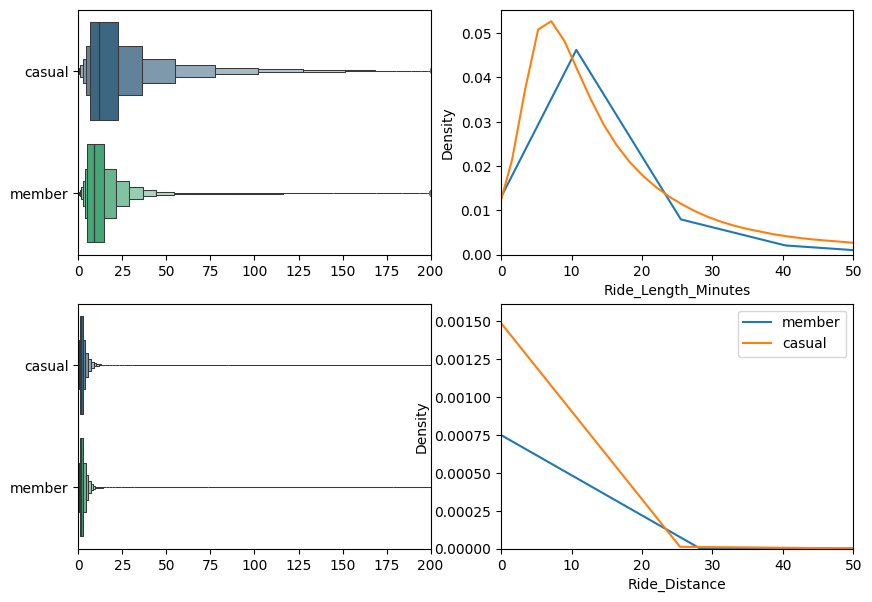

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(10,7))

for i, var in enumerate(['Ride_Length_Minutes', 'Ride_Distance']):    
    # KDE plots
    for user in df['Member_Type'].unique():
        sns.kdeplot(df[df['Member_Type'] == user][var], ax=axes[i,1],fill=False,label=user,palette='viridis')

    # Boxenplot
    sns.boxenplot(x=var, y="Member_Type", data=df,  ax=axes[i,0], palette='viridis')

    axes[i,0].set(xlabel="", ylabel="")
    axes[i,1].set(ylabel="Density")
    axes[i,0].set_xlim(0, 200)
    axes[i,1].set_xlim(0, 50)

plt.legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,7))

variables = ['Ride_Length_Minutes', 'Ride_Distance']

for i, var in enumerate(variables):
    
    # Boxen plot (left column)
    sns.boxenplot(
        x=var, 
        y="Member_Type", 
        data=df, 
        ax=axes[i, 0], 
        palette='viridis'
    )
    
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel("")
    axes[i, 0].set_xlim(0, 100)

    # KDE plot (right column)
    sns.kdeplot(
        data=df,
        x=var,
        hue="Member_Type",
        fill=True,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_ylabel("Density")
    axes[i, 1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [88]:
annual_pivot_month = pd.pivot_table(annual_members, index=months, columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
annual_pivot_month.index = month_names
annual_pivot_month.columns = hours_order

annual_pivot_week = pd.pivot_table(annual_members, index='Day_Of_Week', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
annual_pivot_week.index = week_order
annual_pivot_week.columns = hours_order

annual_pivot_day = pd.pivot_table(annual_members, index=days, columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
annual_pivot_day.index = days_order
annual_pivot_day.columns = hours_order

annual_pivot_season = pd.pivot_table(annual_members, index='Season', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
annual_pivot_season.index = season_order
annual_pivot_season.columns = hours_order

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\374888192.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  annual_pivot_week = pd.pivot_table(annual_members, index='Day_Of_Week', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\374888192.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  annual_pivot_season = pd.pivot_table(annual_members, index='Season', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)


In [89]:
casual_pivot_month = pd.pivot_table(casual_members, index=months, columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
casual_pivot_month.index = month_names
casual_pivot_month.columns = hours_order

casual_pivot_week = pd.pivot_table(casual_members, index='Day_Of_Week', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
casual_pivot_week.index = week_order
casual_pivot_week.columns = hours_order

casual_pivot_day = pd.pivot_table(casual_members, index=days, columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
casual_pivot_day.index = days_order
casual_pivot_day.columns = hours_order

casual_pivot_season = pd.pivot_table(casual_members, index='Season', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
casual_pivot_season.index = season_order
casual_pivot_season.columns = hours_order

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\975239769.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  casual_pivot_week = pd.pivot_table(casual_members, index='Day_Of_Week', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\975239769.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  casual_pivot_season = pd.pivot_table(casual_members, index='Season', columns=hours, values='Ride_ID',  aggfunc='count', fill_value=0, dropna=False)


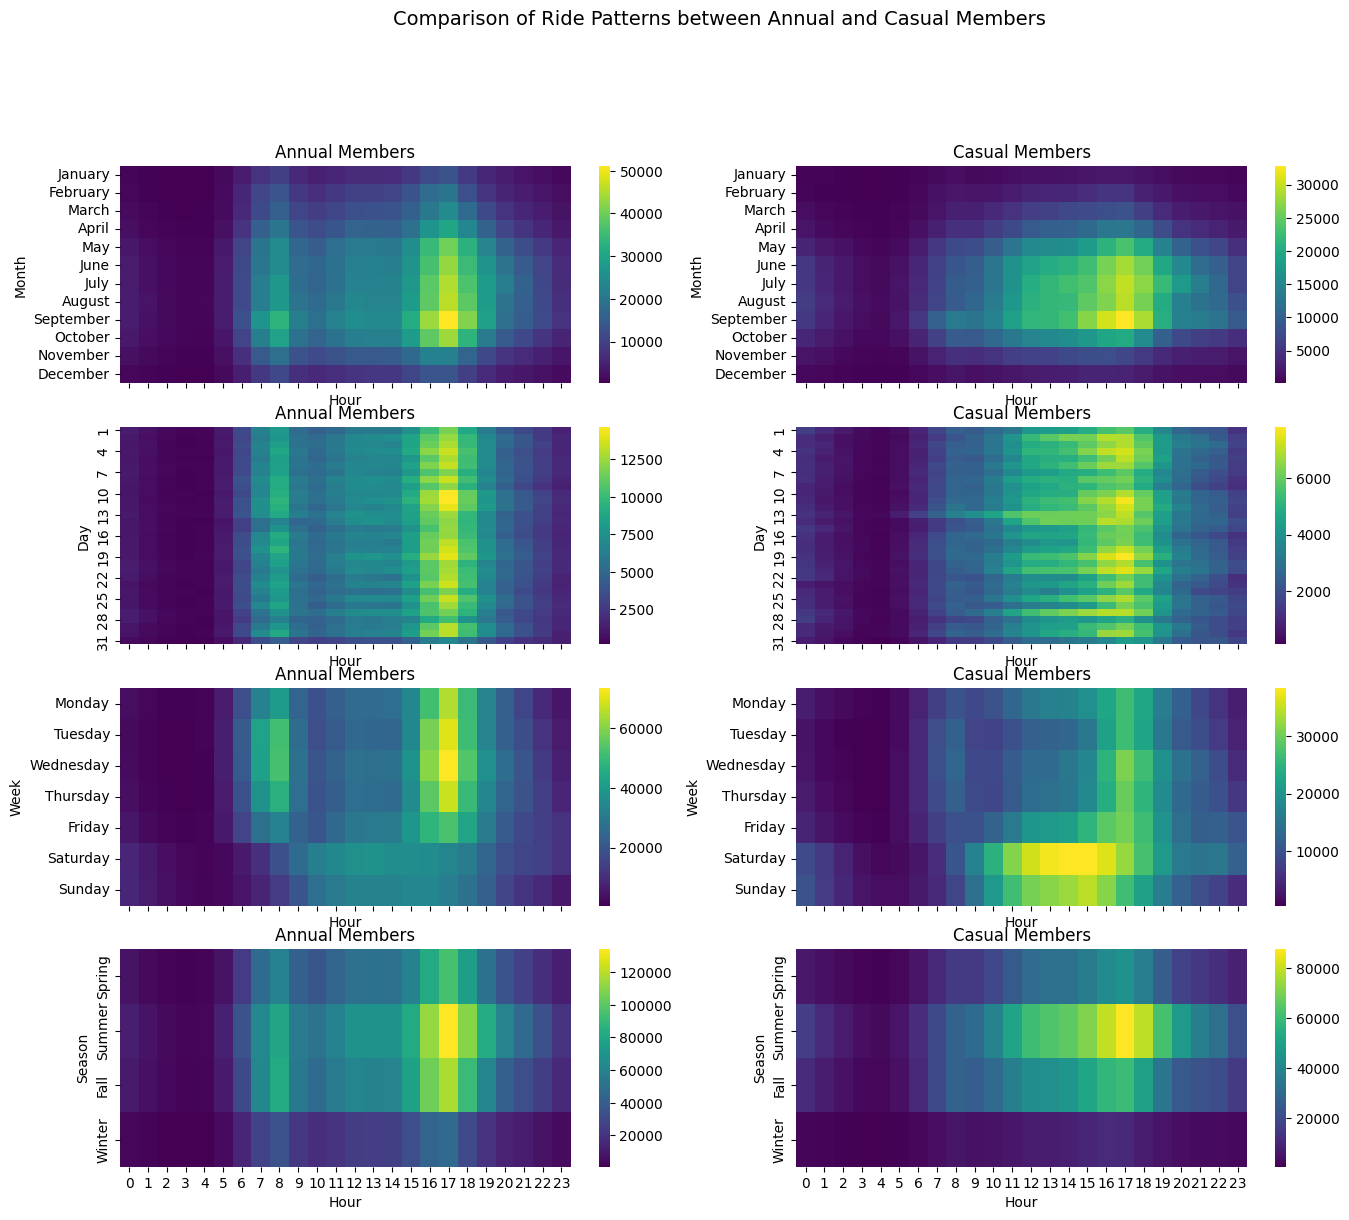

In [ ]:
data1 = {
    'Annual Members': {
        'Month': annual_pivot_month,
        'Day': annual_pivot_day,
        'Week': annual_pivot_week,
        'Season': annual_pivot_season
    },
    'Casual Members': {
        'Month': casual_pivot_month,
        'Day': casual_pivot_day,
        'Week': casual_pivot_week,
        'Season': casual_pivot_season
    }
}

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 15), sharex=True)

# Iterate over data and axes to plot heatmaps
for i, (member_type, pivot_tables) in enumerate(data1.items()):
    for j, (time_period, pivot_table) in enumerate(pivot_tables.items()):
        sns.heatmap(pivot_table, cmap='viridis', fmt='g', cbar=True, ax=axes[j, i])
        axes[j, i].set_xlabel('Hour')
        axes[j, i].set_ylabel(time_period)

        # Set title for each column
        axes[j, i].set_title(member_type)

# Set the overarching title for the entire subplot
suptitle = plt.suptitle("Comparison of Ride Patterns between Annual and Casual Members", fontsize=14)
suptitle.set_y(1)

In [80]:
monthly_min_dist = df.groupby([months, "Member_Type"]).agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']}).reset_index()
week_min_dist = df.groupby(["Day_Of_Week","Member_Type"]).agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']}).reset_index()
hour_min_dist = df.groupby([df["Started_At"].dt.hour,"Member_Type"]).agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']}).reset_index()
season_min_dist = df.groupby(["Season","Member_Type"]).agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']}).reset_index()

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2809229689.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_min_dist = df.groupby([months, "Member_Type"]).agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']}).reset_index()
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2809229689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  week_min_dist = df.groupby(["Day_Of_Week","Member_Type"]).agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']}).reset_index()
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\2809229689.py:3: FutureWarning: T

In [81]:
df.groupby("Member_Type").agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']})

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3658521026.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Member_Type").agg({'Ride_Length_Minutes': ['sum', 'median'],'Ride_Distance': ['sum', 'median']})


Ride_Length_Minutes            Ride_Distance          
                            sum     median           sum    median
Member_Type                                                       
casual             4.096922e+07  11.970350  4.520414e+06  1.581823
member             4.349273e+07   8.683333  8.056009e+06  1.562872

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3828726171.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, j].set_xticklabels(labels=plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3828726171.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, j].set_xticklabels(labels=plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3828726171.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, j].set_xticklabels(labels=plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\3828726171.py:22: UserWarning

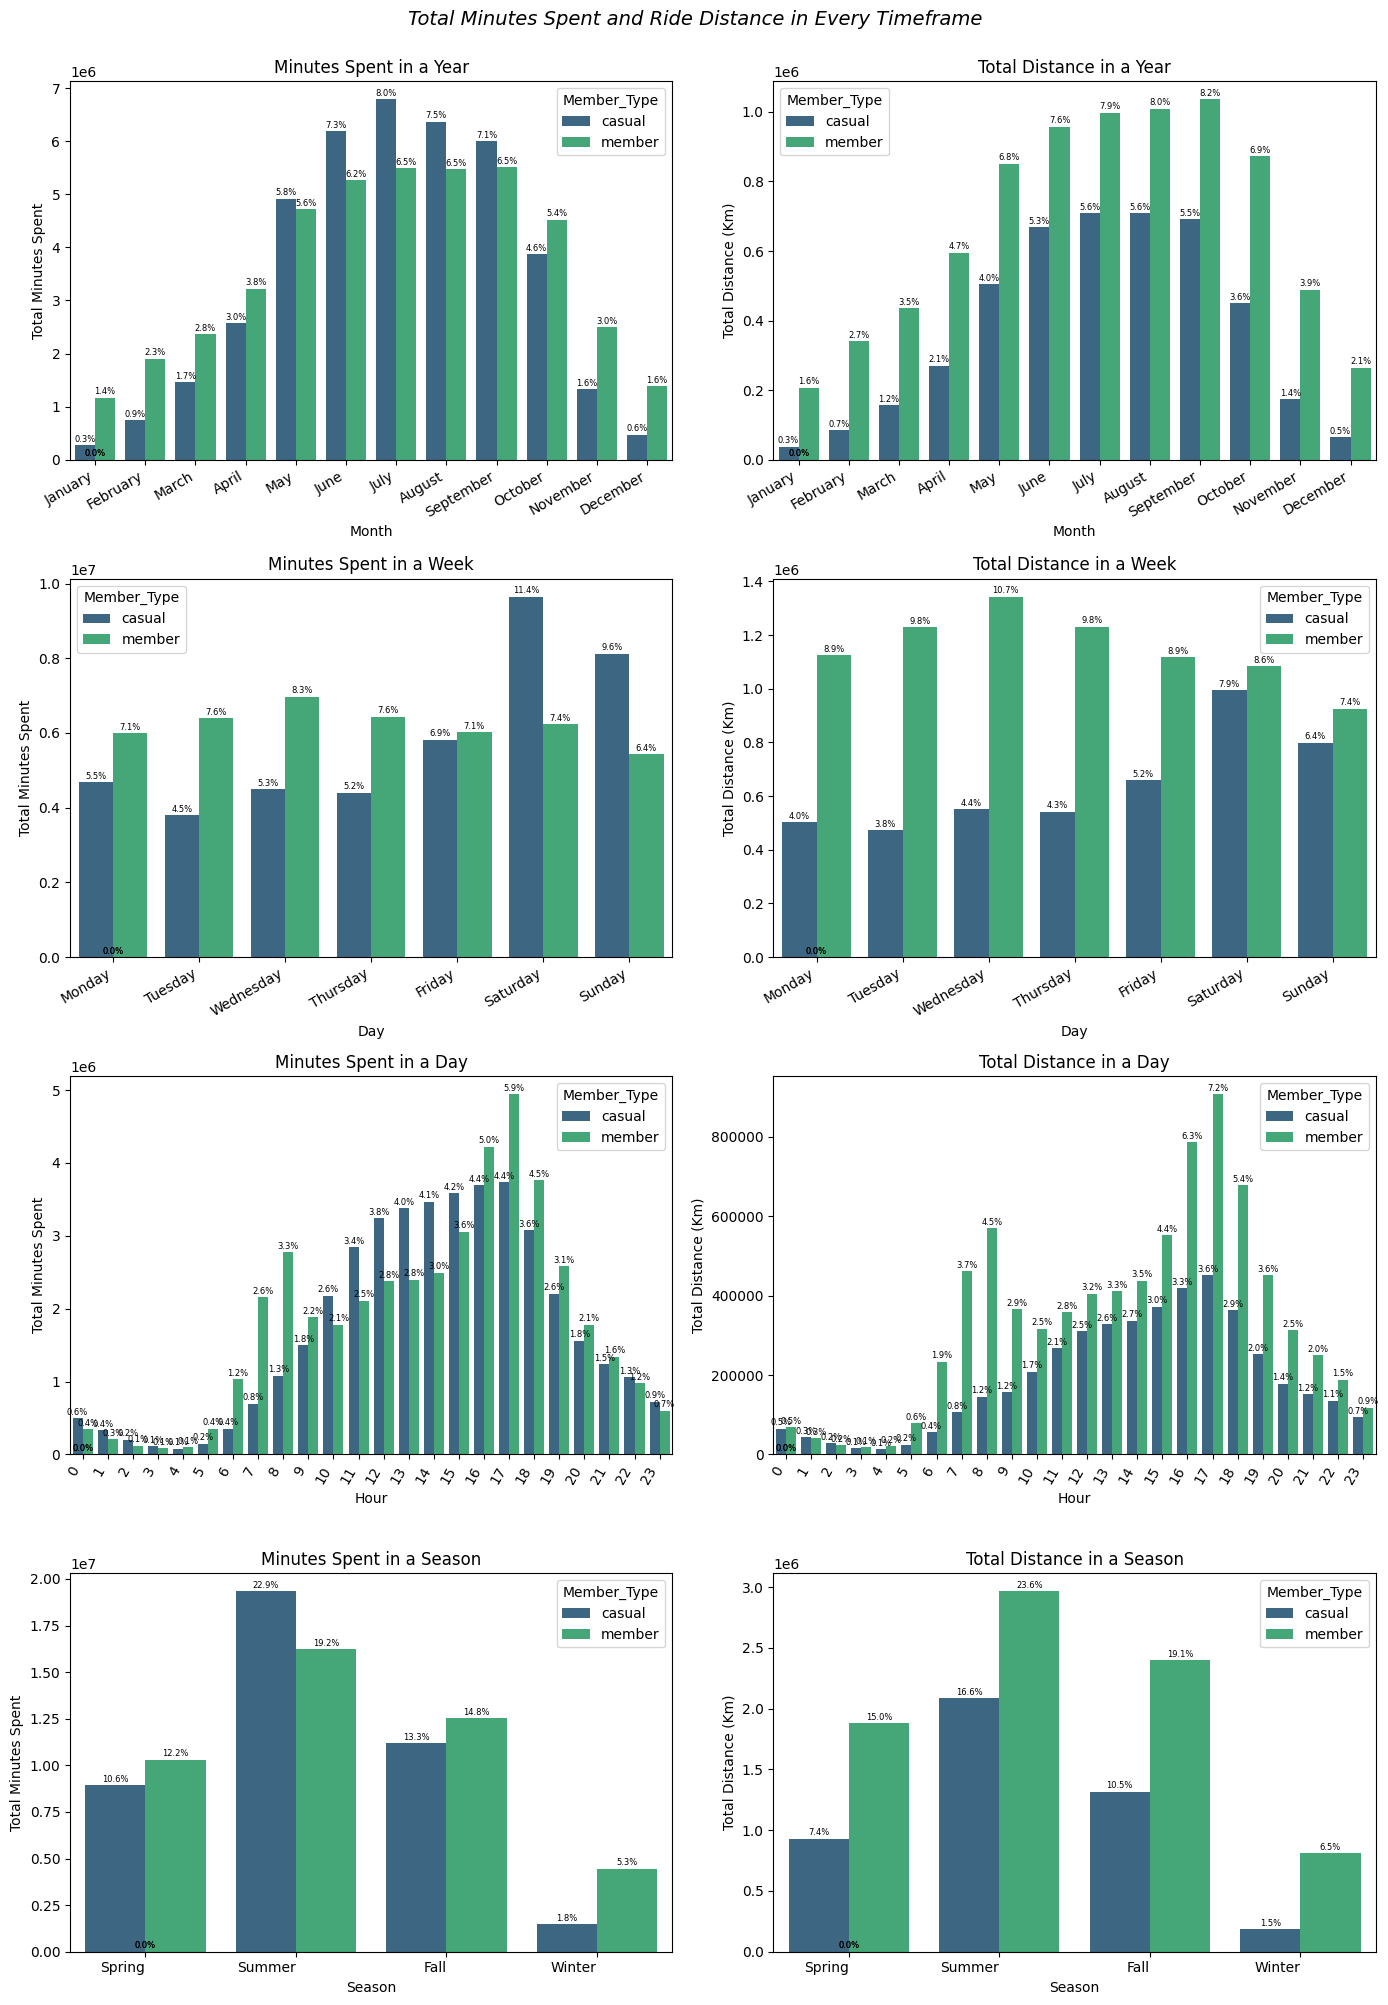

In [132]:
# Define the data and corresponding labels
data = {
    (0,0): {'x': 'Started_At', 'y': ('Ride_Length_Minutes', 'sum'), 'hue': 'Member_Type', 'title': 'Minutes Spent in a Year', 'xlabel': 'Month', 'xticklabels': month_names, 'xtickrotation': 30, 'data': monthly_min_dist},
    (1,0): {'x': 'Day_Of_Week', 'y': ('Ride_Length_Minutes', 'sum'), 'hue': 'Member_Type', 'title': 'Minutes Spent in a Week', 'xlabel': 'Day', 'xticklabels': week_order, 'xtickrotation': 30, 'data': week_min_dist},
    (2,0): {'x': 'Started_At', 'y': ('Ride_Length_Minutes', 'sum'), 'hue': 'Member_Type', 'title': 'Minutes Spent in a Day', 'xlabel': 'Hour', 'xticklabels': hours_order, 'xtickrotation': 60, 'data': hour_min_dist},
    (3,0): {'x': 'Season', 'y': ('Ride_Length_Minutes', 'sum'), 'hue': 'Member_Type', 'title': 'Minutes Spent in a Season', 'xlabel': 'Season', 'xticklabels': season_order, 'xtickrotation': 0, 'data': season_min_dist},
    (0,1): {'x': 'Started_At', 'y': ('Ride_Distance', 'sum'), 'hue': 'Member_Type', 'title': 'Total Distance in a Year', 'xlabel': 'Month', 'xticklabels': month_names, 'xtickrotation': 30, 'data': monthly_min_dist},
    (1,1): {'x': 'Day_Of_Week', 'y': ('Ride_Distance', 'sum'), 'hue': 'Member_Type', 'title': 'Total Distance in a Week', 'xlabel': 'Day', 'xticklabels': week_order, 'xtickrotation': 30, 'data': week_min_dist},
    (2,1): {'x': 'Started_At', 'y': ('Ride_Distance', 'sum'), 'hue': 'Member_Type', 'title': 'Total Distance in a Day', 'xlabel': 'Hour', 'xticklabels': hours_order, 'xtickrotation': 60, 'data': hour_min_dist},
    (3,1): {'x': 'Season', 'y': ('Ride_Distance', 'sum'), 'hue': 'Member_Type', 'title': 'Total Distance in a Season', 'xlabel': 'Season', 'xticklabels': season_order, 'xtickrotation': 0, 'data': season_min_dist}
}

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 20), sharey=False)

# Iterate over the data and axes to plot barplots
for (i, j), plot_data in data.items():
    sns.barplot(x=plot_data['x'], y=plot_data['data'][plot_data['y']], hue=plot_data['hue'],palette='viridis', data=plot_data['data'], ax=axes[i, j])
    axes[i, j].set_title(plot_data['title'])
    axes[i, j].set_xlabel(plot_data['xlabel'])
    axes[i, j].set_ylabel('Total Minutes Spent' if j == 0 else 'Total Distance (Km)')
    axes[i, j].set_xticklabels(labels=plot_data['xticklabels'], rotation=plot_data['xtickrotation'], ha='right')
    
    total_counts = sum([p.get_height() for p in axes[i, j].patches])

    for p in axes[i, j].patches:
        axes[i, j].annotate('{:.1f}%'.format(p.get_height() / total_counts * 100),
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=6, color='black', xytext=(0, 1),
                            textcoords='offset points')
# Set the overarching title for the entire subplot
suptitle = plt.suptitle("Total Minutes Spent and Ride Distance in Every Timeframe", fontsize=14, fontstyle='italic')
suptitle.set_y(1)
plt.tight_layout()
plt.show()

In [84]:

annual_start_station = annual_members.groupby(['Start_Station_Name','Start_Latitude','Start_Longitude'])['Ride_ID'].count().reset_index().rename(columns={"Ride_ID":"Number of Trips"}).sort_values("Number of Trips",ascending=False)
casual_start_station = casual_members.groupby(['Start_Station_Name','Start_Latitude','Start_Longitude'])['Ride_ID'].count().reset_index().rename(columns={"Ride_ID":"Number of Trips"}).sort_values("Number of Trips",ascending=False)

In [85]:
annual_start_station.value_counts('Number of Trips')

Number of Trips
1        637332
2           389
3            76
4            51
5            38
          ...  
16484         1
19235         1
19950         1
20580         1
23470         1
Name: count, Length: 716, dtype: int64

In [86]:
top10_annual = annual_start_station.nlargest(10, 'Number of Trips')
top10_casual = casual_start_station.nlargest(10, 'Number of Trips')

C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1328410647.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Trips', y='Start_Station_Name', data=top10_annual, ax=axes[0], palette='YlGnBu_r')
C:\Users\olisa\AppData\Local\Temp\ipykernel_49752\1328410647.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Trips', y='Start_Station_Name', data=top10_casual, ax=axes[1], palette='YlGnBu_r')


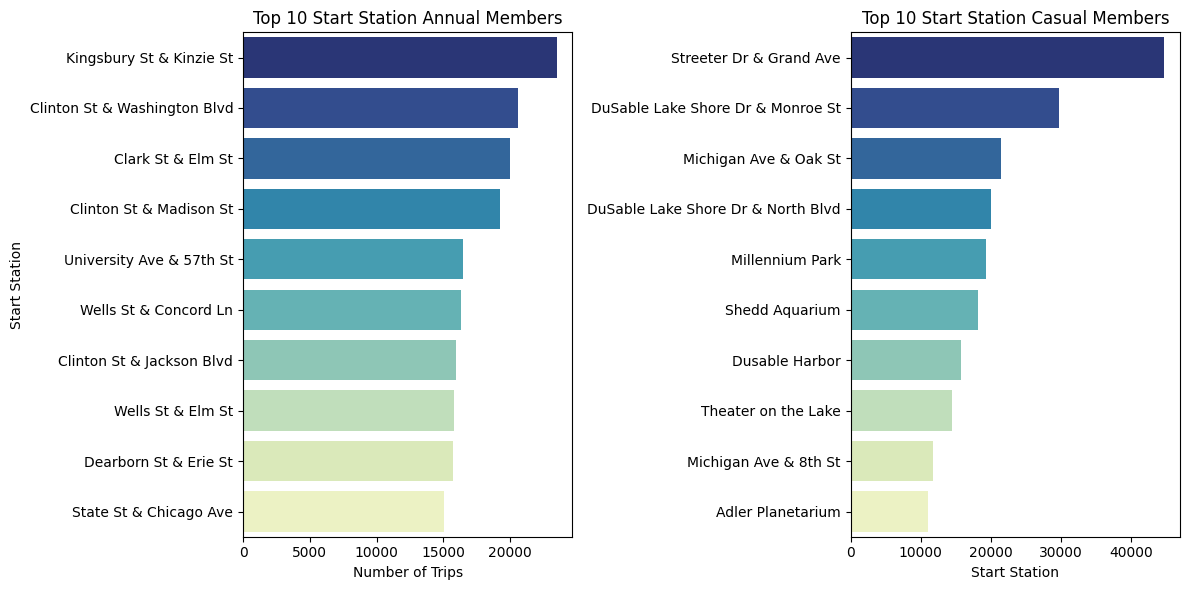

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

sns.barplot(x='Number of Trips', y='Start_Station_Name', data=top10_annual, ax=axes[0], palette='YlGnBu_r')
axes[0].set_title('Top 10 Start Station Annual Members')
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Start Station')

sns.barplot(x='Number of Trips', y='Start_Station_Name', data=top10_casual, ax=axes[1], palette='YlGnBu_r')
axes[1].set_title('Top 10 Start Station Casual Members')
axes[1].set_xlabel('Start Station')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
df.loc[10]
print(type(df.mean()))

: 

: 